In [32]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# ============================================================
# LOAD DATA
# ============================================================

data = np.load("10_DATA_TRPCAGE.npy")[:, :2]

print("Data shape:", data.shape)

# shape = (50000, 38)

# ============================================================
# NORMALIZATION
# ============================================================

#data_mean = data.mean(axis=0)
#data_std  = data.std(axis=0) + 1e-8

#data = (data - data_mean) / data_std

data_tensor = torch.tensor(data, dtype=torch.float32)

dataset = TensorDataset(data_tensor)

# ============================================================
# DATALOADER
# ============================================================

batch_size = 256

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

# ============================================================
# HYPERPARAMETERS
# ============================================================

data_dim = 2
latent_dim = 32
hidden_dim = 128

lr = 2e-4
epochs = 200

# ============================================================
# GENERATOR
# ============================================================

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, data_dim)

        )

    def forward(self, z):
        return self.model(z)

# ============================================================
# DISCRIMINATOR
# ============================================================

class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(data_dim, hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()

        )

    def forward(self, x):
        return self.model(x)

# ============================================================
# MODELS
# ============================================================

G = Generator().to(device)
D = Discriminator().to(device)

# ============================================================
# OPTIMIZERS
# ============================================================

g_optimizer = torch.optim.Adam(
    G.parameters(),
    lr=lr,
    betas=(0.5, 0.999)
)

d_optimizer = torch.optim.Adam(
    D.parameters(),
    lr=lr,
    betas=(0.5, 0.999)
)

# ============================================================
# LOSS
# ============================================================

criterion = nn.BCELoss()

# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(epochs):

    g_loss_epoch = 0.0
    d_loss_epoch = 0.0

    for batch in loader:

        # ====================================================
        # REAL DATA
        # ====================================================

        real = batch[0].to(device)

        B = real.shape[0]

        real_labels = torch.ones(B, 1).to(device)
        fake_labels = torch.zeros(B, 1).to(device)

        # ====================================================
        # TRAIN DISCRIMINATOR
        # ====================================================

        z = torch.randn(B, latent_dim).to(device)

        fake = G(z)

        d_real = D(real)
        d_fake = D(fake.detach())

        d_real_loss = criterion(d_real, real_labels)
        d_fake_loss = criterion(d_fake, fake_labels)

        d_loss = d_real_loss + d_fake_loss

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # ====================================================
        # TRAIN GENERATOR
        # ====================================================

        z = torch.randn(B, latent_dim).to(device)

        fake = G(z)

        d_fake = D(fake)

        # generator wants discriminator to predict REAL

        g_loss = criterion(d_fake, real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # ====================================================
        # LOGGING
        # ====================================================

        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()

    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D Loss: {d_loss_epoch/len(loader):.4f} "
        f"G Loss: {g_loss_epoch/len(loader):.4f}"
    )

# ============================================================
# SAVE MODELS
# ============================================================

torch.save(G.state_dict(), "generator.pt")
torch.save(D.state_dict(), "discriminator.pt")

print("Models saved.")

# ============================================================
# GENERATE NEW SAMPLES
# ============================================================

G.eval()

with torch.no_grad():

    z = torch.randn(1000, latent_dim).to(device)

    generated = G(z).cpu().numpy()

# ============================================================
# DENORMALIZE
# ============================================================

generated = generated * data_std + data_mean

# ============================================================
# SAVE GENERATED DATA
# ============================================================

np.save("generated_samples.npy", generated)

print("Generated samples shape:", generated.shape)

Using device: cpu
Data shape: (50000, 2)
Epoch [1/200] D Loss: 1.3236 G Loss: 0.7877
Epoch [2/200] D Loss: 1.3215 G Loss: 0.7451
Epoch [3/200] D Loss: 1.3181 G Loss: 0.7637
Epoch [4/200] D Loss: 1.3226 G Loss: 0.7482
Epoch [5/200] D Loss: 1.3234 G Loss: 0.7631
Epoch [6/200] D Loss: 1.3163 G Loss: 0.7666
Epoch [7/200] D Loss: 1.3147 G Loss: 0.7565
Epoch [8/200] D Loss: 1.3180 G Loss: 0.7513
Epoch [9/200] D Loss: 1.3245 G Loss: 0.7471
Epoch [10/200] D Loss: 1.3161 G Loss: 0.7467
Epoch [11/200] D Loss: 1.3123 G Loss: 0.7485
Epoch [12/200] D Loss: 1.3296 G Loss: 0.7781
Epoch [13/200] D Loss: 1.3251 G Loss: 0.7699
Epoch [14/200] D Loss: 1.3191 G Loss: 0.7502
Epoch [15/200] D Loss: 1.3213 G Loss: 0.7481
Epoch [16/200] D Loss: 1.3548 G Loss: 0.7297
Epoch [17/200] D Loss: 1.3583 G Loss: 0.7241
Epoch [18/200] D Loss: 1.3615 G Loss: 0.7251
Epoch [19/200] D Loss: 1.3596 G Loss: 0.7267
Epoch [20/200] D Loss: 1.3578 G Loss: 0.7281
Epoch [21/200] D Loss: 1.3545 G Loss: 0.7280
Epoch [22/200] D Loss: 

Epoch [181/200] D Loss: 1.3622 G Loss: 0.7173
Epoch [182/200] D Loss: 1.3630 G Loss: 0.7180
Epoch [183/200] D Loss: 1.3626 G Loss: 0.7184
Epoch [184/200] D Loss: 1.3620 G Loss: 0.7181
Epoch [185/200] D Loss: 1.3608 G Loss: 0.7178
Epoch [186/200] D Loss: 1.3621 G Loss: 0.7174
Epoch [187/200] D Loss: 1.3623 G Loss: 0.7208
Epoch [188/200] D Loss: 1.3621 G Loss: 0.7177
Epoch [189/200] D Loss: 1.3632 G Loss: 0.7182
Epoch [190/200] D Loss: 1.3628 G Loss: 0.7187
Epoch [191/200] D Loss: 1.3624 G Loss: 0.7175
Epoch [192/200] D Loss: 1.3619 G Loss: 0.7185
Epoch [193/200] D Loss: 1.3636 G Loss: 0.7178
Epoch [194/200] D Loss: 1.3624 G Loss: 0.7177
Epoch [195/200] D Loss: 1.3630 G Loss: 0.7184
Epoch [196/200] D Loss: 1.3627 G Loss: 0.7181
Epoch [197/200] D Loss: 1.3625 G Loss: 0.7175
Epoch [198/200] D Loss: 1.3601 G Loss: 0.7194
Epoch [199/200] D Loss: 1.3617 G Loss: 0.7196
Epoch [200/200] D Loss: 1.3629 G Loss: 0.7182
Models saved.


ValueError: operands could not be broadcast together with shapes (1000,2) (38,) 

# Imports ...

In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


# DEVICE


In [4]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu



# LOAD DATA


In [5]:


data = np.load("10_DATA_TRPCAGE.npy")

print("Data shape:", data.shape)

# shape = (50000, 38)

Data shape: (50000, 38)



# NORMALIZATION


In [ ]:
# Not required here

#data_mean = data.mean(axis=0)
#data_std  = data.std(axis=0) + 1e-8

#data = (data - data_mean) / data_std


# Convert data to tensor 

In [6]:


data_tensor = torch.tensor(data, dtype=torch.float32)

dataset = TensorDataset(data_tensor)


# Data Loader

In [7]:


batch_size = 256

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)


# HYPERPARAMETERS


In [8]:


data_dim = 38
latent_dim = 32
hidden_dim = 128

lr = 2e-4
epochs = 200



# GENERATOR


In [9]:


class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, data_dim)

        )

    def forward(self, z):
        return self.model(z)



# DISCRIMINATOR



In [10]:

class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(data_dim, hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()

        )

    def forward(self, x):
        return self.model(x)


# Initialize MODELS for training 


In [11]:


G = Generator().to(device)
D = Discriminator().to(device)



# Initialize  OPTIMIZERS for training

In [12]:


g_optimizer = torch.optim.Adam(
    G.parameters(),
    lr=lr,
    betas=(0.5, 0.999)
)

d_optimizer = torch.optim.Adam(
    D.parameters(),
    lr=lr,
    betas=(0.5, 0.999)
)


# Define LOSS


In [13]:


criterion = nn.BCELoss()


# TRAINING LOOP


In [14]:


g_losses = []
d_losses = []

for epoch in range(epochs):

    g_loss_epoch = 0.0
    d_loss_epoch = 0.0

    for batch in loader:

        # ====================================================
        # REAL DATA
        # ====================================================

        real = batch[0].to(device)

        B = real.shape[0]

        real_labels = torch.ones(B, 1).to(device)
        fake_labels = torch.zeros(B, 1).to(device)

        # ====================================================
        # TRAIN DISCRIMINATOR
        # ====================================================

        z = torch.randn(B, latent_dim).to(device)

        fake = G(z)

        d_real = D(real)
        d_fake = D(fake.detach())

        d_real_loss = criterion(d_real, real_labels)
        d_fake_loss = criterion(d_fake, fake_labels)

        d_loss = d_real_loss + d_fake_loss

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # ====================================================
        # TRAIN GENERATOR
        # ====================================================

        z = torch.randn(B, latent_dim).to(device)

        fake = G(z)

        d_fake = D(fake)

        # generator tries to fool discriminator

        g_loss = criterion(d_fake, real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # ====================================================
        # LOGGING
        # ====================================================

        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()

    # ========================================================
    # AVERAGE LOSSES
    # ========================================================

    avg_g_loss = g_loss_epoch / len(loader)
    avg_d_loss = d_loss_epoch / len(loader)

    g_losses.append(avg_g_loss)
    d_losses.append(avg_d_loss)

    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D Loss: {avg_d_loss:.4f} "
        f"G Loss: {avg_g_loss:.4f}"
    )



Epoch [1/200] D Loss: 0.9793 G Loss: 0.8781
Epoch [2/200] D Loss: 0.7145 G Loss: 1.9522
Epoch [3/200] D Loss: 0.5505 G Loss: 2.2386
Epoch [4/200] D Loss: 0.7079 G Loss: 1.9950
Epoch [5/200] D Loss: 0.5370 G Loss: 2.1938
Epoch [6/200] D Loss: 0.6920 G Loss: 2.2040
Epoch [7/200] D Loss: 0.6190 G Loss: 2.1108
Epoch [8/200] D Loss: 0.7151 G Loss: 1.8043
Epoch [9/200] D Loss: 0.8689 G Loss: 1.7857
Epoch [10/200] D Loss: 0.9926 G Loss: 1.4498
Epoch [11/200] D Loss: 0.8207 G Loss: 1.4181
Epoch [12/200] D Loss: 0.9753 G Loss: 1.5314
Epoch [13/200] D Loss: 0.9809 G Loss: 1.4557
Epoch [14/200] D Loss: 0.9488 G Loss: 1.4070
Epoch [15/200] D Loss: 1.0451 G Loss: 1.4679
Epoch [16/200] D Loss: 0.8284 G Loss: 1.4657
Epoch [17/200] D Loss: 0.9054 G Loss: 1.5076
Epoch [18/200] D Loss: 0.9640 G Loss: 1.4871
Epoch [19/200] D Loss: 1.0966 G Loss: 1.2908
Epoch [20/200] D Loss: 0.9640 G Loss: 1.2532
Epoch [21/200] D Loss: 0.9741 G Loss: 1.5383
Epoch [22/200] D Loss: 1.0401 G Loss: 1.4629
Epoch [23/200] D Lo

Epoch [182/200] D Loss: 0.8984 G Loss: 1.6209
Epoch [183/200] D Loss: 0.8869 G Loss: 1.5833
Epoch [184/200] D Loss: 0.8869 G Loss: 1.5607
Epoch [185/200] D Loss: 0.8934 G Loss: 1.6038
Epoch [186/200] D Loss: 0.9257 G Loss: 1.5436
Epoch [187/200] D Loss: 0.9100 G Loss: 1.5853
Epoch [188/200] D Loss: 0.9053 G Loss: 1.5523
Epoch [189/200] D Loss: 0.9207 G Loss: 1.5538
Epoch [190/200] D Loss: 0.8965 G Loss: 1.6019
Epoch [191/200] D Loss: 0.9188 G Loss: 1.5494
Epoch [192/200] D Loss: 0.9187 G Loss: 1.5756
Epoch [193/200] D Loss: 0.9212 G Loss: 1.5506
Epoch [194/200] D Loss: 0.9020 G Loss: 1.5627
Epoch [195/200] D Loss: 0.9185 G Loss: 1.5487
Epoch [196/200] D Loss: 0.9085 G Loss: 1.5370
Epoch [197/200] D Loss: 0.8951 G Loss: 1.5713
Epoch [198/200] D Loss: 0.9236 G Loss: 1.5553
Epoch [199/200] D Loss: 0.8924 G Loss: 1.5385
Epoch [200/200] D Loss: 0.9110 G Loss: 1.5811



# SAVE MODELS



In [15]:


torch.save(G.state_dict(), "generator.pt")
torch.save(D.state_dict(), "discriminator.pt")

print("Models saved.")

Models saved.



# SAVE LOSSES


In [16]:



np.save("g_losses.npy", np.array(g_losses))
np.save("d_losses.npy", np.array(d_losses))

print("Losses saved.")

Losses saved.



# PLOT LOSSES


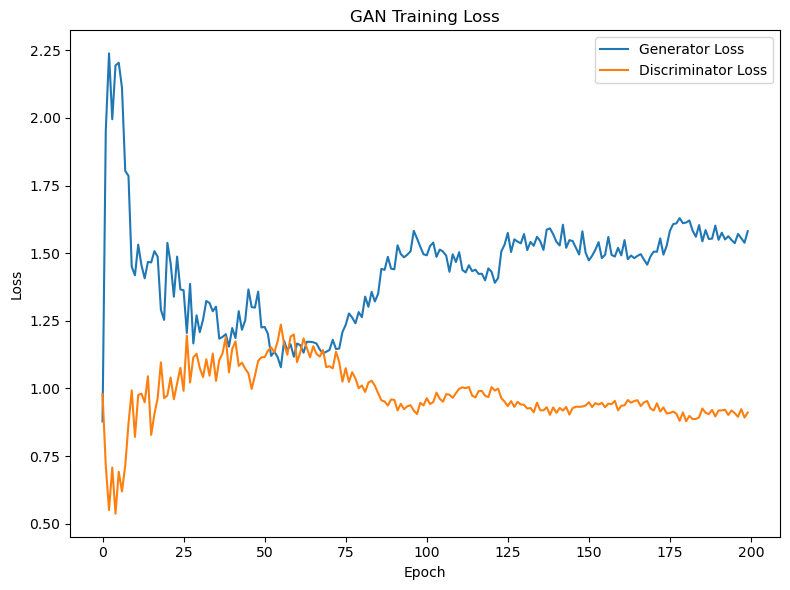

In [18]:


import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("GAN Training Loss")

plt.legend()

plt.tight_layout()

plt.savefig("gan_losses.png", dpi=300)

plt.show()


# GENERATE NEW SAMPLES


In [35]:


G.eval()

with torch.no_grad():

    z = torch.randn(50000, latent_dim).to(device)

    generated = G(z).cpu().numpy()

In [36]:
# ============================================================
# DENORMALIZE
# ============================================================

generated = generated  
real_data = data
# ============================================================
# SAVE GENERATED DATA
# ============================================================

np.save("generated_samples.npy", generated)

print("Generated samples shape:", generated.shape)

Generated samples shape: (50000, 2)


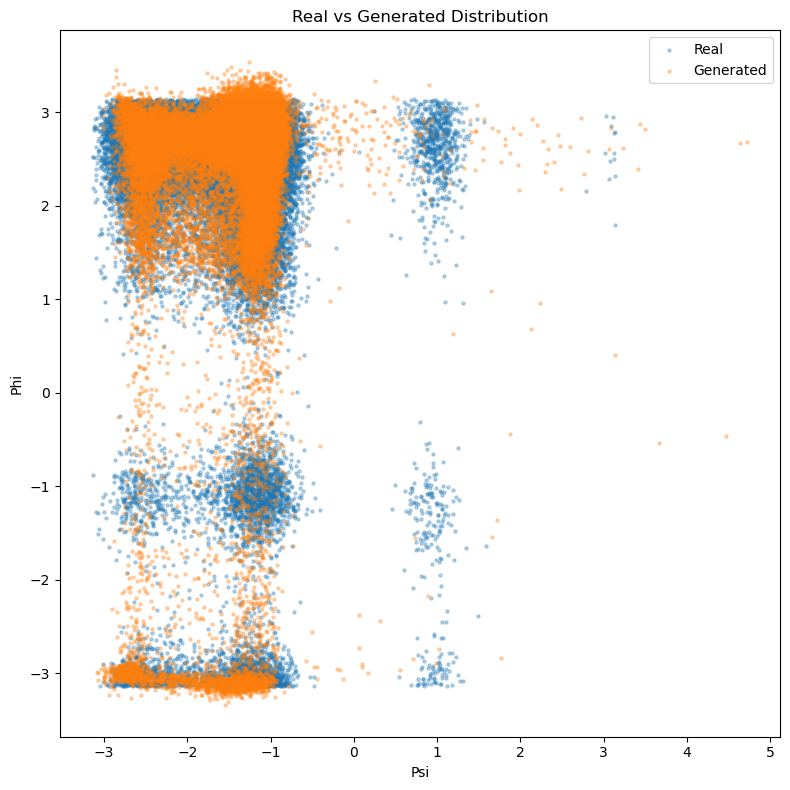

In [37]:
# ============================================================
# COMPARE REAL VS GENERATED
# ============================================================

import matplotlib.pyplot as plt

# assuming:
# dim 0 = psi
# dim 1 = phi

psi_real = real_data[:, 0]
phi_real = real_data[:, 1]

psi_fake = generated[:, 0]
phi_fake = generated[:, 1]

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(8,8))

plt.scatter(
    psi_real,
    phi_real,
    s=5,
    alpha=0.3,
    label="Real"
)

plt.scatter(
    psi_fake,
    phi_fake,
    s=5,
    alpha=0.3,
    label="Generated"
)

plt.xlabel("Psi")
plt.ylabel("Phi")

plt.title("Real vs Generated Distribution")

plt.legend()

plt.tight_layout()

plt.savefig("real_vs_generated.png", dpi=300)

plt.show()

# Generate from saved model ...

Real data shape: (50000, 2)
Generator loaded.
Generated shape: (50000, 2)


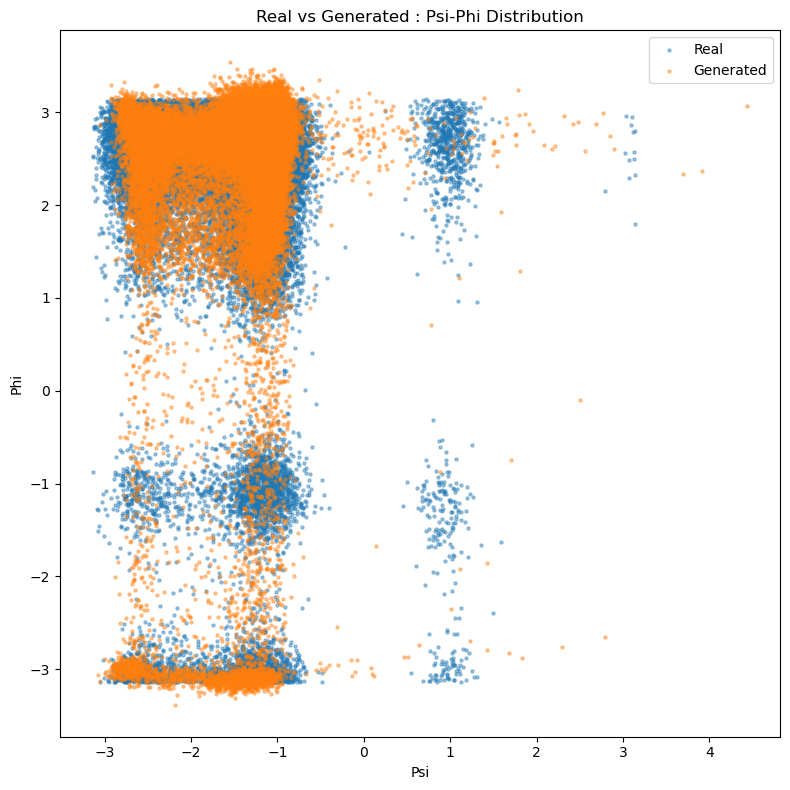

In [34]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# LOAD REAL DATA
# ============================================================

real_data = np.load("10_DATA_TRPCAGE.npy")[:,:2]

print("Real data shape:", real_data.shape)

# ============================================================
# NORMALIZATION STATS
# ============================================================

data_mean = real_data.mean(axis=0)
data_std  = real_data.std(axis=0) + 1e-8

normalized_real = (real_data - data_mean) / data_std

# ============================================================
# HYPERPARAMETERS
# ============================================================

data_dim = 2
latent_dim = 32
hidden_dim = 128

# ============================================================
# GENERATOR ARCHITECTURE
# ============================================================

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),

            nn.Linear(hidden_dim, data_dim)

        )

    def forward(self, z):
        return self.model(z)

# ============================================================
# LOAD TRAINED GENERATOR
# ============================================================

G = Generator().to(device)

G.load_state_dict(
    torch.load("generator.pt", map_location=device)
)

G.eval()

print("Generator loaded.")

# ============================================================
# SAMPLE GENERATED DATA
# ============================================================

num_samples = 50000

with torch.no_grad():

    z = torch.randn(num_samples, latent_dim).to(device)

    generated = G(z).cpu().numpy()

# ============================================================
# DENORMALIZE
# ============================================================

generated = generated # * data_std + data_mean

print("Generated shape:", generated.shape)

# ============================================================
# PSI / PHI DIMENSIONS
# ============================================================

# assuming:
# dim 0 = psi
# dim 1 = phi

psi_real = real_data[:, 0]
phi_real = real_data[:, 1]

psi_fake = generated[:, 0]
phi_fake = generated[:, 1]

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(8,8))

plt.scatter(
    psi_real,
    phi_real,
    s=5,
    alpha=0.4,
    label="Real"
)

plt.scatter(
    psi_fake,
    phi_fake,
    s=5,
    alpha=0.4,
    label="Generated"
)

plt.xlabel("Psi")
plt.ylabel("Phi")

plt.title("Real vs Generated : Psi-Phi Distribution")

plt.legend()

plt.tight_layout()

plt.show()